# Supplementary Codes

In [1]:
# Connect to Google Drive

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd

# Read data from Google Drive.
# Data is already clean.

file_path = "/content/drive/MyDrive/Doutorado CAV 2024/Análises no Colab/JSTARS_153_samples.csv"
data = pd.read_csv(file_path, decimal=',')

# Separate response and predictor variables

X = data.iloc[:, 14:221]  # Spectral bands
y = data['V_hectare']     # Volume to be predicted

Calculating Moran's I for different K-nearest Neighbors:
  k=1: Moran's I = 0.8139, p-value = 0.0010 (Statistically Significant)
  k=2: Moran's I = 0.7806, p-value = 0.0010 (Statistically Significant)
  k=3: Moran's I = 0.7784, p-value = 0.0010 (Statistically Significant)
  k=4: Moran's I = 0.7779, p-value = 0.0010 (Statistically Significant)
  k=5: Moran's I = 0.7669, p-value = 0.0010 (Statistically Significant)
  k=6: Moran's I = 0.7661, p-value = 0.0010 (Statistically Significant)
  k=7: Moran's I = 0.7561, p-value = 0.0010 (Statistically Significant)
  k=8: Moran's I = 0.7443, p-value = 0.0010 (Statistically Significant)
  k=9: Moran's I = 0.7413, p-value = 0.0010 (Statistically Significant)
  k=10: Moran's I = 0.7299, p-value = 0.0010 (Statistically Significant)


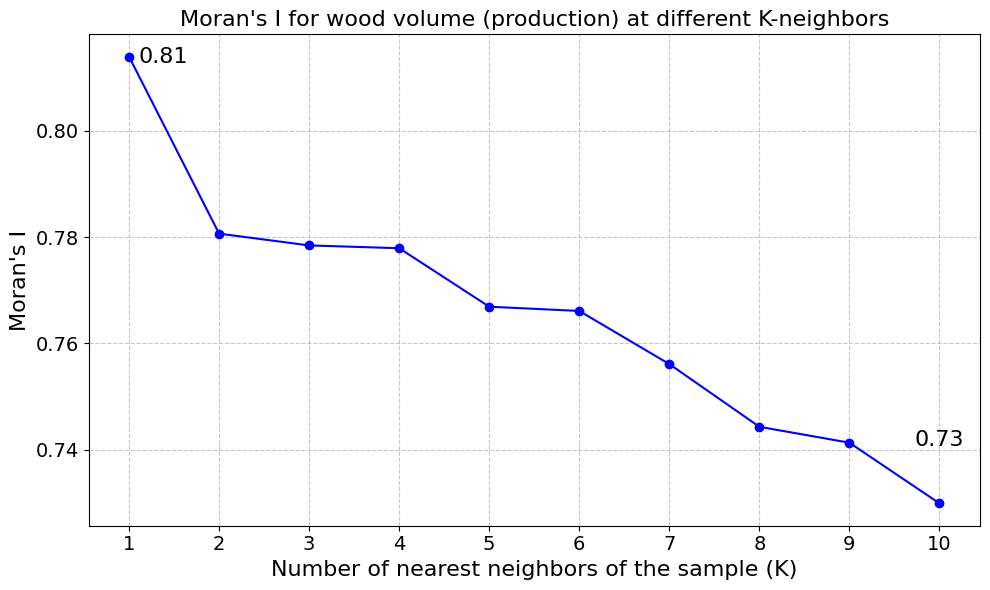


Interpretation of Significance (level 0.05):
A p-value of less than 0.05 indicates sufficient evidence to reject the null hypothesis that spatial autocorrelation is random. In other words, the observed Moran's I values ​​are statistically significant, and the variable 'V_hectare' exhibits a non-random spatial pattern (clustered or dispersed).
In this case, spatial autocorrelation is positive and significant for all tested K values, indicating that plots with similar 'V_hectare' values ​​tend to be located close to one another.


In [4]:
import libpysal
from esda.moran import Moran
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Extract coordinates and target variable from the 'dados' DataFrame
# Using 'X' and 'Y' for coordinates and 'V_hectare' for the target,
# based on the notebook's state and previous cells.
coords_moran = data[['X', 'Y']].values
target_variable = data['V_hectare']

# Define the k-values for which to calculate Moran's I
k_values = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

moran_i_values = []
p_values = [] # Optional: to store p-values as well

# Define the significance level for interpretation
significance_level = 0.05

print("Calculating Moran's I for different K-nearest Neighbors:")
for k in k_values:
    # Step 3.1: Define the spatial weights matrix (K-nearest neighbors)
    # Suppress UserWarning about disconnected components, as it's often expected for sparse data
    import warnings
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        knn_weights = libpysal.weights.KNN.from_array(coords_moran, k=k)
        knn_weights.transform = 'r'  # Row-standardization

    # Step 3.2: Calculate Moran's I for the target variable
    moran = Moran(target_variable, knn_weights)
    moran_i_values.append(moran.I)
    p_values.append(moran.p_sim)

    # Interpret significance
    is_significant = "Statistically Significant" if moran.p_sim < significance_level else "Not Statistically Significant"
    print(f"  k={k}: Moran's I = {moran.I:.4f}, p-value = {moran.p_sim:.4f} ({is_significant})")

# Generate a line plot of Moran's I values
plt.figure(figsize=(10, 6))
plt.plot(k_values, moran_i_values, marker='o', linestyle='-', color='blue')
plt.title("Moran's I for wood volume (production) at different K-neighbors", fontsize=16)
plt.xlabel("Number of nearest neighbors of the sample (K)", fontsize=16)
plt.ylabel("Moran's I", fontsize=16)

# Increase font size for x and y tick labels
plt.tick_params(axis='x', labelsize=14)
plt.tick_params(axis='y', labelsize=14)

plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(k_values)

# --- Adjust offset for k=1 label ---
offset_x_k1 = 0.1 # Positive value moves right, negative moves left

# Add Moran's I values for k=1 and k=10 on the plot
moran_i_k1 = moran_i_values[0]
plt.text(k_values[0] + offset_x_k1, moran_i_k1, f'{moran_i_k1:.2f}', fontsize=16, ha='left', va='center')

moran_i_k10 = moran_i_values[9]
plt.text(k_values[9], moran_i_k10 + 0.01, f'{moran_i_k10:.2f}', fontsize=16, ha='center', va='bottom')

plt.tight_layout()
# Save the graph figure at a resolution of 600 dpi.
plt.savefig('moran_i_plot.png', dpi=600)
plt.show()

print(f"\nInterpretation of Significance (level {significance_level}):")
print("A p-value of less than 0.05 indicates sufficient evidence to reject the null hypothesis that spatial autocorrelation is random. In other words, the observed Moran's I values ​​are statistically significant, and the variable 'V_hectare' exhibits a non-random spatial pattern (clustered or dispersed).")
print("In this case, spatial autocorrelation is positive and significant for all tested K values, indicating that plots with similar 'V_hectare' values ​​tend to be located close to one another.")


--- ASpatial Cross-Validation Evaluation (LeaveOneGroupOut) ---

Generating distribution map of 4 spatial blocks...


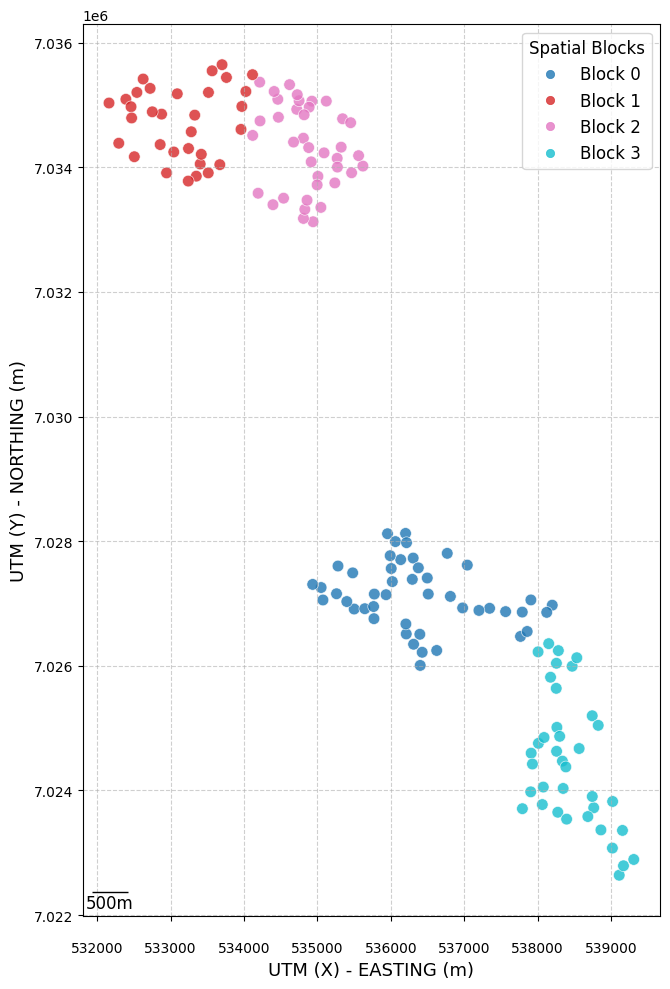

In [8]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
import matplotlib.font_manager as fm # Import to configure the scale bar font.
SEED = 42
coords_full_dataset = data[['X', 'Y']].values

print("\n--- ASpatial Cross-Validation Evaluation (LeaveOneGroupOut) ---")

n_spatial_blocks_cv = 4 # Definido como 4
kmeans_spatial_cv = KMeans(n_clusters=n_spatial_blocks_cv, random_state=SEED, n_init='auto')
blocos_cv = kmeans_spatial_cv.fit_predict(coords_full_dataset)


# --- Visualization of Spatial Blocks ---
print(f"\nGenerating distribution map of {n_spatial_blocks_cv} spatial blocks...")
fig, ax = plt.subplots(figsize=(8, 10))

scatter = ax.scatter(
    coords_full_dataset[:, 0],
    coords_full_dataset[:, 1],
    c=blocos_cv,
    cmap='tab10',
    s=70,
    alpha=0.8,
    edgecolors='w', linewidth=0.5
)

legend_elements = scatter.legend_elements()[0]
labels = [f'Block {i}' for i in range(n_spatial_blocks_cv)] # Changed label to Portuguese

# Adjust legend position to top-right corner of the plot area
ax.legend(legend_elements, labels,
          title="Spatial Blocks",
          loc="upper right",
          title_fontsize=12, # Title font size
          fontsize=12) # loc='upper right' for top-right inside axes

#ax.set_title('Distribution of the Blocks', fontsize=14, pad=15)
ax.set_xlabel('UTM (X) - EASTING (m)', fontsize=13)
ax.set_ylabel('UTM (Y) - NORTHING (m)', fontsize=13)

# Increase X-axis label spacing
ax.tick_params(axis='x', which='major', pad=15) # Increased padding for X-axis labels

ax.grid(True, linestyle='--', alpha=0.6)

# Add a scale bar to the bottom-left corner
# sizex: length of the scale bar in data units (meters for UTM)
# label: text to display for the scale bar
# loc: position in the axes, 'lower left' for bottom-left
# frameon: set to False to remove the frame around the scale bar
# pad: padding around the scale bar
# size_vertical: thickness of the scale bar line
fontprops = fm.FontProperties(size=12) # Definir propriedades da fonte para a barra de escala
scalebar = AnchoredSizeBar(ax.transData, # O transform do Axes é importante
                           500, # size_x: comprimento da barra de escala em unidades de dados (500 metros)
                           '500m', # label: texto para exibir
                           loc='lower left', # Posição
                           pad=0.1, # preenchimento
                           color='black', # Cor da barra
                           frameon=False, # Sem moldura
                           size_vertical=1, # Espessura da barra
                           fontproperties=fontprops # Propriedades da fonte
                          )
ax.add_artist(scalebar)

plt.tight_layout(rect=[0, 0, 0.85, 1]) # Adjust layout to make space for legend (original code had a legend, so this is good practice)
fig.savefig('spatial_blocks_distribution.png', dpi=600)
plt.show()

In our preliminary tests using the methods presented in this study, it was not possible to fit any of the models using spatial cross-validation. Consequently, we chose not to present the code for this step, and the metrics in the corresponding table in the paper are listed as Not Adjusted or fitted (NA).